# Craig Transform

Transforming $G_{UV},\,G_{NE}$ to $g_{D}$

The Craig transform provides functionality to generate gravity from differential curvatures.

Here we demonstrate its use on publicly available data from the Fosterville Falcon airborne gravity gradiometer survey.

This a first draft of the Craig Transform tutorial.

___
Import the required modules, and set the path to the geowhizz files.

In [4]:
# import numpy as np
# from scipy.fftpack import fft2
# import matplotlib.pyplot as plt
# # %matplotlib widget
# import xarray as xr
# import xrft
# from scipy.interpolate import RegularGridInterpolator

from pathlib import Path
import pegasusQC as qc
# from pegasusQC.gridFiles.gridutility import report_gridStats

# Use Fosterville data for example with non-rectangular boundary

data_root = r'/Volumes/MHD Data2024/TestData/2019_Falcon_Fosterville/'
FostervilleHDF_file = Path(data_root + r'803064_AGG_Located_20191108_EL3539.hdf5')

reg_root = r'/Volumes/MHD Data2024/TestData/2019_Falcon_Fosterville/regional/'
regional_fa_ers = Path(reg_root + r'Gravmap2019-grid-grv_fa.ers')

In [5]:
if not FostervilleHDF_file.exists():
    print("Ask Mark for help!!!")
    # %run ./Prepare_EastVicData.ipynb

In [6]:
# Find the channel names for the free-air Gne and Guv data
qc.reportChannels(FostervilleHDF_file)

Whizz Version 1.0

50 channels:


50 channels:
 ['Date_Local', 'Diff_AmB_NE_2p67_0p18HzLP', 'Diff_AmB_UV_2p67_0p18HzLP', 'Elevation_GNSS_EGM96', 'Elevation_GNSS_GRS80', 'Falc_A_NE_0p00_0p18Hz_MeanLev', 'Falc_A_NE_2p67_0p18Hz_MeanLev', 'Falc_A_UV_0p00_0p18Hz_MeanLev', 'Falc_A_UV_2p67_0p18Hz_MeanLev', 'Falc_B_NE_0p00_0p18Hz_MeanLev', 'Falc_B_NE_2p67_0p18Hz_MeanLev', 'Falc_B_UV_0p00_0p18Hz_MeanLev', 'Falc_B_UV_2p67_0p18Hz_MeanLev', 'Falc_Corr_TC_DD_1p00_0p18HzLP_TCGrid_DSM_EGM96', 'Falc_Corr_TC_NE_1p00_0p18HzLP_TCGrid_DSM_EGM96', 'Falc_Corr_TC_UV_1p00_0p18HzLP_TCGrid_DSM_EGM96', 'Falc_GDD_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GDD_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GED_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GED_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GEE_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GEE_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GND_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GND_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GNE_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GNE_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GNN_0p00_0p18HzLP_ESD300m_SDS',

Perhaps that does not help everyone. I need to remove un-needed channels for this tutorial!! Anyway, I can see the names I want, and put them in the call below.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_NE_0p00_0p18Hz_MeanLev: min = -51.8, max = 39.8, mean = 0.0262.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_UV_0p00_0p18Hz_MeanLev: min = -41.5, max = 67.7, mean = -0.312.

Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_NE_0p00_0p18Hz_MeanLev). Falc_A_NE_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
1 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_UV_0p00_0p18Hz_MeanLev). Falc_A_UV_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
1 point(s) excluded.
Creating minimum curvature grid...
Finished!
Wavenumber resolution = 8.882177910023506e-06
Wavenumber resolution = 1.3422818791946484e-05
im_min:  -105.334777526

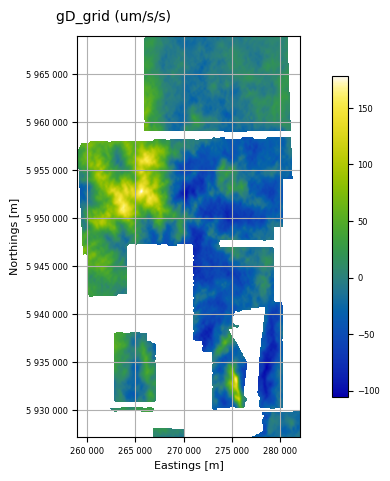

RMS of result = 26.95
Array shape = (418, 233)


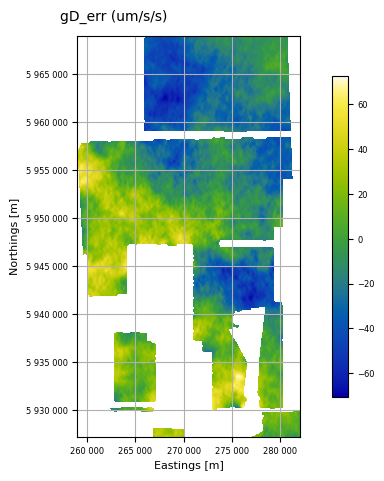

In [9]:
gD_grid, Ane_grid = qc.craig_transform(
    whizzFile=FostervilleHDF_file, gne_chan='Falc_A_NE_0p00_0p18Hz_MeanLev', guv_chan='Falc_A_UV_0p00_0p18Hz_MeanLev',
    cell_size=100.0, unit_scale=1000.0, mask_polygon=None,
    pad_cells=256, padding_mode="regional", regional_grid_file=regional_fa_ers
)